<a href="https://colab.research.google.com/github/Bibhuti-MLAI/Time-Series-Forcasting/blob/main/Revenue_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_absolute_percentage_error

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
data_path = r"/content/drive/MyDrive/Alma Better/Revenue Forcasting/bfsi_revenue_forecasting_project/data/BFSI_Revenue_Forecasting_Dataset.xlsx"
RANDOM_STATE = 42

In [2]:
customer = pd.read_excel(data_path, sheet_name="Customer_Master")

In [3]:
customer.head()

,customer_id,customer_name,segment,industry,onboarding_date,credit_limit,risk_grade,geography
0,CUST00056,Client Enterprises 56,Medium,Pharma,15/11/18,10926167.91,C,NaN
1,CUST00052,Client Enterprises 52,Micro,Logistics,07/24/2018,25541292.36,B,Telangana
2,CUST00002,Client Enterprises 2,MSME,Logistics,17-10-2021,29729379.37,A,Maharashtra
3,CUST00089,Client Enterprises 89,SME,IT Services,04/18/2022,14092573.62,A,Delhi NCR
4,CUST00048,Client Enterprises 48,SME,Textiles,03/09/18,29928698.10,A+,Karnataka


In [4]:
invoice = pd.read_excel(data_path, sheet_name="Invoice_Data")
payment = pd.read_excel(data_path, sheet_name="Payment_Data")
repayment =pd.read_excel(data_path, sheet_name="Repayment_Data")

In [5]:
customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 113 entries, 0 to 112
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   customer_id      113 non-null    object 
 1   customer_name    113 non-null    object 
 2   segment          113 non-null    object 
 3   industry         113 non-null    object 
 4   onboarding_date  113 non-null    object 
 5   credit_limit     104 non-null    float64
 6   risk_grade       98 non-null     object 
 7   geography        107 non-null    object 
dtypes: float64(1), object(7)
memory usage: 7.2+ KB


In [6]:
customer.describe().T

,count,mean,std,min,25%,50%,75%,max
credit_limit,104.0,2.464384e+07,1.384461e+07,583718.27,12734032.6,2.558577e+07,35548554.17,49400676.43


In [7]:
customer['customer_id'].count()

np.int64(113)

Clean Customer_master

In [8]:
customer['customer_id']= customer['customer_id'].astype(str).str.strip().str.upper()

In [9]:
customer

,customer_id,customer_name,segment,industry,onboarding_date,credit_limit,risk_grade,geography
0,CUST00056,Client Enterprises 56,Medium,Pharma,15/11/18,10926167.91,C,NaN
1,CUST00052,Client Enterprises 52,Micro,Logistics,07/24/2018,25541292.36,B,Telangana
2,CUST00002,Client Enterprises 2,MSME,Logistics,17-10-2021,29729379.37,A,Maharashtra
3,CUST00089,Client Enterprises 89,SME,IT Services,04/18/2022,14092573.62,A,Delhi NCR
4,CUST00048,Client Enterprises 48,SME,Textiles,03/09/18,29928698.10,A+,Karnataka
...,...,...,...,...,...,...,...,...
108,CUST00029,Client Enterprises 29,MSME,IT Services,20/09/18,8673784.47,A+,TN
109,CUST00096,Client Enterprises 96,Large,IT Services,13-07-2019,19748431.56,NaN,West Bengal
110,CUST00016,Client Enterprises 16,MSME,IT Services,12-Mar-2019,44291816.12,NaN,MH
111,CUST00091,Client Enterprises 91,Small,Auto Ancillary,11/05/2018,35467747.51,A,West Bengal


In [10]:
digits = customer['customer_id'].str.extract(r"CUST0*(\d+)")[0]
customer["customer_id"] = "CUST" + digits.str.zfill(5)
customer["customer_id"].head()

,customer_id
0,CUST00056
1,CUST00052
2,CUST00002
3,CUST00089
4,CUST00048


In [11]:
digits

,0
0,56
1,52
2,2
3,89
4,48
...,...
108,29
109,96
110,16
111,91


In [12]:
customer["customer_name"] = customer["customer_name"].astype(str).str.strip()

In [13]:
customer["onboarding_date"] =pd.to_datetime(customer["onboarding_date"],dayfirst=True,errors="coerce")
customer[["customer_id","customer_name","onboarding_date"]].head()

/tmp/ipykernel_1708/2456310456.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  customer["onboarding_date"] =pd.to_datetime(customer["onboarding_date"],dayfirst=True,errors="coerce")


,customer_id,customer_name,onboarding_date
0,CUST00056,Client Enterprises 56,2018-11-15
1,CUST00052,Client Enterprises 52,2018-07-24
2,CUST00002,Client Enterprises 2,2021-10-17
3,CUST00089,Client Enterprises 89,2022-04-18
4,CUST00048,Client Enterprises 48,2018-09-03


In [14]:
from numpy._core.defchararray import title
#standardise free text categories
customer["industry"] = customer["industry"].astype(str).str.strip().str.title()
customer["geography"] = customer["geography"].astype(str).str.strip().str.title()
customer["geography"] = customer["geography"].replace({"Mh":"Maharastra","Tn":"Tamil nadu"})
customer.loc[customer["geography"].isin(["Nan","None"]),"geography"] = np.nan

customer["segment"] = customer["segment"].astype(str).str.strip().str.title()
customer["segment"] = customer["segment"].replace({"Sme":"SME","Msme":"MSME"})
customer[["segment","industry","geography"]].head()

,segment,industry,geography
0,Medium,Pharma,NaN
1,Micro,Logistics,Telangana
2,MSME,Logistics,Maharashtra
3,SME,It Services,Delhi Ncr
4,SME,Textiles,Karnataka


In [15]:
before  = len(customer)
customer = customer.sort_values("customer_id").drop_duplicates(subset="customer_id",keep = "first")
print(f"Customer_master:{before} -> {len(customer)} rows after removing duplicates")

Customer_master:113 -> 110 rows after removing duplicates


In [16]:
#Missing Values
print("Missing Values : ")
print(customer[["geography","credit_limit","risk_grade"]].isna().sum())

Missing Values : 
geography        6
credit_limit     9
risk_grade      15
dtype: int64


In [17]:
customer["geography"] = customer['geography'].fillna("Unknown")
customer["credit_limit"] = customer.groupby("segment")["credit_limit"].transform(lambda x: x.fillna(x.median()))
customer["credit_limit"] = customer["credit_limit"].fillna(customer["credit_limit"].median())
customer['risk_grade'] = customer["risk_grade"].fillna("Unrated")

print("Missing after")
print(customer[["geography","credit_limit","risk_grade"]].isna().sum())

Missing after
geography       0
credit_limit    0
risk_grade      0
dtype: int64


Cleaning Invoice data

In [18]:
invoice["customer_id"] = invoice["customer_id"].astype(str).str.strip().str.upper()
digits = invoice["customer_id"].str.extract(r"CUST0*(\D+)")[0]

invoice["invoice_date"] = pd.to_datetime(invoice["invoice_date"], dayfirst=True, errors = "coerce")
invoice["due_date"] = pd.to_datetime(invoice["due_date"],dayfirst=True,errors = "coerce")
invoice["invoice_status"] = invoice["invoice_status"].astype(str).str.strip().str.title()
invoice["discounting_flag"] = invoice["discounting_flag"].astype(str).str.strip().str.upper()
invoice.head()

/tmp/ipykernel_1708/1418042568.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  invoice["invoice_date"] = pd.to_datetime(invoice["invoice_date"], dayfirst=True, errors = "coerce")


,invoice_id,customer_id,invoice_date,invoice_amount,due_date,invoice_status,discounting_flag
0,INV0001348,CUST00072,2023-09-25,60110.08,2023-10-25,Open,Y
1,INV0001541,CUST00083,2022-09-13,60974.11,NaT,Paid,Y
2,INV0001936,CUST00105,2022-03-02,74165.65,2022-04-16,Partially Paid,N
3,INV0000293,CUST00015,2022-08-20,97633.69,NaT,Paid,N
4,INV0000372,CUST00020,2023-05-15,104900.40,NaT,Overdue,Y


In [19]:
before = len(invoice)
invoice = invoice.drop_duplicates()
print(f"invoice_data:removed {before - len(invoice)} extract duplicate rows")

invoice_data:removed 5 extract duplicate rows


In [20]:
valid_customer_ids = set(customer["customer_id"])
is_orphan = ~invoice["customer_id"].isin(valid_customer_ids)
print(f"Invoice_data: {is_orphan.sum()} orphan invoices - excluding")
invoice = invoice[~is_orphan]

Invoice_data: 27 orphan invoices - excluding


In [21]:
is_orphan.count()

np.int64(2044)

In [22]:
n_negative = (invoice["invoice_amount"] < 0).sum()
print(f"Invoice_data : {n_negative} negative invoice amount rows - excluding")
invoice = invoice[invoice["invoice_amount"].isna() | (invoice["invoice_amount"] >=0)]

Invoice_data : 1 negative invoice amount rows - excluding


In [23]:
n_missing  = (invoice["invoice_amount"].isna().sum())
invoice = invoice.dropna(subset= ["invoice_amount"])
print(f"Invoice_data: Dropped {n_missing} rows with missing invoice_amount")

Invoice_data: Dropped 59 rows with missing invoice_amount


In [24]:
cap = invoice["invoice_amount"].quantile(0.995)
n_capped = (invoice["invoice_amount"] > cap).sum()
invoice["invoice_amount_capped"] = invoice["invoice_amount"].clip(upper=cap)
print(f"Invoice_data: capped {n_capped} outlier rows at rupees {cap :,.0f}")
invoice.shape

Invoice_data: capped 10 outlier rows at rupees 1,001,775


(1957, 8)

In [25]:
invoice.head()

,invoice_id,customer_id,invoice_date,invoice_amount,due_date,invoice_status,discounting_flag,invoice_amount_capped
0,INV0001348,CUST00072,2023-09-25,60110.08,2023-10-25,Open,Y,60110.08
1,INV0001541,CUST00083,2022-09-13,60974.11,NaT,Paid,Y,60974.11
2,INV0001936,CUST00105,2022-03-02,74165.65,2022-04-16,Partially Paid,N,74165.65
3,INV0000293,CUST00015,2022-08-20,97633.69,NaT,Paid,N,97633.69
4,INV0000372,CUST00020,2023-05-15,104900.40,NaT,Overdue,Y,104900.40


In [26]:
#Clean Payment data
payment["customer_id"] = payment["customer_id"].astype(str).str.strip().str.upper()
digits = payment["customer_id"].str.extract(r"CUST0*(\d+)")[0]
payment["customer_id"] = "CUST" +digits.str.zfill(5)

payment["payment_date"] = pd.to_datetime(payment["payment_date"], dayfirst=True, errors = "coerce")
payment["payment_mode"] = payment["payment_mode"].astype(str).str.strip().str.upper()
payment["payment_mode"] = payment["payment_mode"].replace({"WIRE TRANSFER" : "WIRE"})

before =len(payment)
payment = payment.drop_duplicates()
print(f"Payment_Data: removed {before - len(payment)} exact duplicate rows")

Payment_Data: removed 4 exact duplicate rows


/tmp/ipykernel_1708/99731555.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  payment["payment_date"] = pd.to_datetime(payment["payment_date"], dayfirst=True, errors = "coerce")


In [27]:
# Orphan payments: invoice_id not present in the cleaned Invoice_Data
valid_invoice_ids = set(invoice["invoice_id"])
is_orphan = ~payment["invoice_id"].isin(valid_invoice_ids)
print(f"payment_data : {is_orphan.sum()} orphan paymnet - excluding")
payment = payment[~is_orphan]

payment_data : 17 orphan paymnet - excluding


In [28]:
n_missing_fee = payment["fee_charged"].isna().sum()
payment["fee_charged"] = payment["fee_charged"].fillna(0)
print(f"Payment_Data: {n_missing_fee} missing fee_charged -> filled with 0")
payment.shape

Payment_Data: 72 missing fee_charged -> filled with 0


(1188, 7)

In [29]:
#Clean Repayment Data
repayment["customer_id"] = repayment["customer_id"].astype(str).str.strip().str.upper()
digits = repayment['customer_id'].str.extract(r"CUST0(\d+)")[0]
repayment["customer_id"] = "CUST" + digits.str.zfill(5)

repayment["repayment_date"] = pd.to_datetime(repayment["repayment_date"],dayfirst = True,errors="coerce")
repayment["overdue_flag"] = repayment["overdue_flag"].astype(str).str.strip().str.upper()

before = len(repayment)
repayment= repayment = repayment.drop_duplicates()
print(f"Repayment_Data: removed {before - len(repayment)} exact duplicate rows")

Repayment_Data: removed 3 exact duplicate rows


In [30]:
invoice_customer_map =invoice.set_index("invoice_id")["customer_id"]
corrected = repayment["invoice_id"].map(invoice_customer_map)
n_mismatch = (corrected.notna() & (corrected != repayment["customer_id"])).sum()
print(f"Repayment_date: Correcting {n_mismatch} customer_id values that disagreed with the linked invoice")

repayment.loc[corrected.notna(), "customer_id"] = corrected[corrected.notna()]

n_unmatched = corrected.isna().sum()
repayment = repayment[corrected.notna()]
print(f"Repayment_date: dropped {n_unmatched} rows with no matching invoice_id")

Repayment_date: Correcting 3 customer_id values that disagreed with the linked invoice
Repayment_date: dropped 11 rows with no matching invoice_id


In [31]:
#missing discount_income
n_missing_income = repayment["discount_income"].isna().sum()
repayment = repayment.dropna(subset=["discount_income"])
print(f"Repayment_Date: dropped {n_missing_income} rows with missing discount income")

Repayment_Date: dropped 47 rows with missing discount income


In [32]:
bad_dpd = repayment["dpd"] == -9999
print(f"Repayment_date: fixing {bad_dpd.sum()} placeholder dpd values")

Repayment_date: fixing 2 placeholder dpd values


In [33]:
median_dpd = repayment.loc[repayment["dpd"] != -9999, "dpd"].median()
repayment.loc[bad_dpd & (repayment["overdue_flag"] == "N"), "dpd"] = 0
repayment.loc[bad_dpd & (repayment["overdue_flag"] != "N"), "dpd"] =median_dpd
repayment.shape

(908, 8)

In [34]:
#reconsilation
paid_per_invoice =payment.groupby("invoice_id")["payment_amount"].sum()
recon = invoice.set_index("invoice_id")[["invoice_amount"]].copy()
recon["total_paid"] = paid_per_invoice
recon["total_paid"] = recon["total_paid"].fillna(0)
recon["variance_pct"]  = ((recon["total_paid"] - recon["invoice_amount"]) / recon["invoice_amount"]).abs()

flagged = recon[recon["variance_pct"] > 0.02]
print(f"{len(flagged)} / {len(recon)} invoices have payment variance beyond 2% tolerance")

926 / 1957 invoices have payment variance beyond 2% tolerance


Build the customer * month Panel

This is the grain the model actually needs : one row per customer per month

In [35]:
invoice["month"] = invoice["invoice_date"].dt.to_period("M").dt.to_timestamp()
payment["month"] = payment["payment_date"].dt.to_period("M").dt.to_timestamp()
repayment["month"] = repayment['repayment_date'].dt.to_period("M").dt.to_timestamp()

In [36]:
# Invoice activity per customer-month
invoice_monthly = invoice.groupby(["customer_id", "month"]).agg(
    invoice_count=("invoice_id", "count"),
    invoice_value=("invoice_amount_capped", "sum"),
    avg_invoice_size=("invoice_amount_capped", "mean"),
    pct_discounted=("discounting_flag", lambda x: (x == "Y").mean()),
).reset_index()
invoice_monthly.head()

,customer_id,month,invoice_count,invoice_value,avg_invoice_size,pct_discounted
0,CUST00001,2022-01-01,1,60479.25,60479.25,1.0
1,CUST00001,2022-09-01,2,449759.88,224879.94,1.0
2,CUST00001,2023-01-01,2,170657.00,85328.50,0.5
3,CUST00001,2023-06-01,1,27384.34,27384.34,0.0
4,CUST00001,2023-07-01,1,65050.82,65050.82,0.0


In [37]:
#fee income monthly
payment_monthly = payment.groupby(["customer_id","month"]).agg(
    fee_income = ("fee_charged","sum"),
    payment_count = ("payment_id" ,"count"),
).reset_index()

payment_monthly.head()

,customer_id,month,fee_income,payment_count
0,CUST00001,2023-09-01,217.60,1
1,CUST00001,2024-02-01,81.30,1
2,CUST00001,2024-12-01,0.00,1
3,CUST00001,2025-01-01,3989.31,6
4,CUST00002,2024-12-01,4468.77,10


In [38]:
#discount_income + DPD behaviour per customer - month
repayment_monthly = repayment.groupby(["customer_id" , "month"]).agg(
    discount_income = ("discount_income" ,"sum"),
    avg_dpd = ("dpd" , "mean"),
    pct_overdue = ("overdue_flag" , lambda x: (x=="Y").mean()),
    repayment_count = ("repayment_id" , "count"),
).reset_index()

repayment_monthly.head()


,customer_id,month,discount_income,avg_dpd,pct_overdue,repayment_count
0,CUST00001,2024-12-01,8258.47,-2.0,0.0,1
1,CUST00001,2025-01-01,2949.07,23.0,1.0,2
2,CUST00002,2025-01-01,1158.71,17.0,1.0,1
3,CUST00003,2024-12-01,898.91,-1.0,0.0,1
4,CUST00003,2025-01-01,6981.63,16.0,1.0,1


In [39]:
#Build the full customer * month grid, so "no activity" becomes an explicit 0
#insted of missing row

all_months = pd.date_range (invoice["month"].min(),invoice["month"].max(),freq="MS")
panel = pd.MultiIndex.from_product(
    [customer["customer_id"].unique(), all_months], names=["customer_id","month"]
).to_frame(index=False)
panel.head()

,customer_id,month
0,CUST00001,2022-01-01
1,CUST00001,2022-02-01
2,CUST00001,2022-03-01
3,CUST00001,2022-04-01
4,CUST00001,2022-05-01


In [40]:
panel = panel.merge(invoice_monthly,on = ["customer_id" , "month"], how ="left")
panel = panel.merge(payment_monthly, on=["customer_id", "month"], how="left")
panel = panel.merge(repayment_monthly, on=["customer_id", "month"], how="left")

zero_fill_cols = ["invoice_count", "invoice_value", "fee_income", "payment_count",
                   "discount_income", "repayment_count", "pct_discounted", "pct_overdue"]
panel[zero_fill_cols] = panel[zero_fill_cols].fillna(0)
panel.head(10)

,customer_id,month,invoice_count,invoice_value,avg_invoice_size,pct_discounted,fee_income,payment_count,discount_income,avg_dpd,pct_overdue,repayment_count
0,CUST00001,2022-01-01,1.0,60479.25,60479.25,1.0,0.0,0.0,0.0,NaN,0.0,0.0
1,CUST00001,2022-02-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0
2,CUST00001,2022-03-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0
3,CUST00001,2022-04-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0
4,CUST00001,2022-05-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0
5,CUST00001,2022-06-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0
6,CUST00001,2022-07-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0
7,CUST00001,2022-08-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0
8,CUST00001,2022-09-01,2.0,449759.88,224879.94,1.0,0.0,0.0,0.0,NaN,0.0,0.0
9,CUST00001,2022-10-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,0.0,0.0


## 8. Build the targets: revenue, expense, profitability

**ASSUMPTION:** no expense table exists in the source data, so monthly
cost-to-serve is modeled as three components (replace with real cost-center
allocations when available):
- `funding_cost` — cost of capital on discounted invoices, ~8% p.a. prorated monthly
- `ops_cost` — a fixed cost per transaction handled
- `credit_cost` — a provisioning proxy scaled by overdue severity

In [41]:
panel["total_revenue"] = panel["discount_income"] + panel["fee_income"]

FUNDING_RATE_ANNUAL = 0.08
OPS_COST_PER_TXN = 150
CREDIT_COST_RATE = 0.015

panel["funding_cost"] = panel["invoice_value"] * (FUNDING_RATE_ANNUAL/12)
panel["ops_cost"] = (panel["invoice_count"] + panel["payment_count"]) * OPS_COST_PER_TXN
panel["credit_cost"] = panel["invoice_value"] + panel["pct_overdue"] * CREDIT_COST_RATE
panel["total_expense"] = panel["funding_cost"] + panel["ops_cost"] +panel["credit_cost"]

panel["profitability"] = panel["total_revenue"] +panel["total_expense"]
panel[["total_revenue" , "total_expense" , "profitability"]].describe()

,total_revenue,total_expense,profitability
count,3960.000000,3.960000e+03,3.960000e+03
mean,152.441699,7.402253e+04,7.417497e+04
std,1032.599183,1.504300e+05,1.504549e+05
min,0.000000,0.000000e+00,0.000000e+00
25%,0.000000,0.000000e+00,0.000000e+00
50%,0.000000,0.000000e+00,0.000000e+00
75%,0.000000,9.296194e+04,9.301050e+04
max,33343.790000,1.653429e+06,1.653429e+06


In [42]:
panel = panel.merge(
    customer[["customer_id" , "segment" , "industry" , "geography" , "risk_grade" ,
                              "credit_limit" , "onboarding_date"]],
on = "customer_id" , how="left"
)
print(f"panel: {panel.shape[0]} rows , {panel["customer_id"].nunique()} customer x {panel["month"].nunique()} months")
panel.head()

panel: 3960 rows , 110 customer x 36 months


,customer_id,month,invoice_count,invoice_value,avg_invoice_size,pct_discounted,fee_income,payment_count,discount_income,avg_dpd,...,ops_cost,credit_cost,total_expense,profitability,segment,industry,geography,risk_grade,credit_limit,onboarding_date
0,CUST00001,2022-01-01,1.0,60479.25,60479.25,1.0,0.0,0.0,0.0,NaN,...,150.0,60479.25,61032.445,61032.445,Micro,Manufacturing,Karnataka,B,12622146.76,2021-08-02
1,CUST00001,2022-02-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,...,0.0,0.00,0.000,0.000,Micro,Manufacturing,Karnataka,B,12622146.76,2021-08-02
2,CUST00001,2022-03-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,...,0.0,0.00,0.000,0.000,Micro,Manufacturing,Karnataka,B,12622146.76,2021-08-02
3,CUST00001,2022-04-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,...,0.0,0.00,0.000,0.000,Micro,Manufacturing,Karnataka,B,12622146.76,2021-08-02
4,CUST00001,2022-05-01,0.0,0.00,NaN,0.0,0.0,0.0,0.0,NaN,...,0.0,0.00,0.000,0.000,Micro,Manufacturing,Karnataka,B,12622146.76,2021-08-02


In [43]:
panel_full = panel.copy()

**EDA**

In [44]:
panel[["total_revenue", "total_expense", "profitability", "discount_income" , "fee_income"]].describe().round(0)

,total_revenue,total_expense,profitability,discount_income,fee_income
count,3960.0,3960.0,3960.0,3960.0,3960.0
mean,152.0,74023.0,74175.0,44.0,108.0
std,1033.0,150430.0,150455.0,584.0,768.0
min,0.0,0.0,0.0,0.0,0.0
25%,0.0,0.0,0.0,0.0,0.0
50%,0.0,0.0,0.0,0.0,0.0
75%,0.0,92962.0,93011.0,0.0,0.0
max,33344.0,1653429.0,1653429.0,20050.0,33344.0


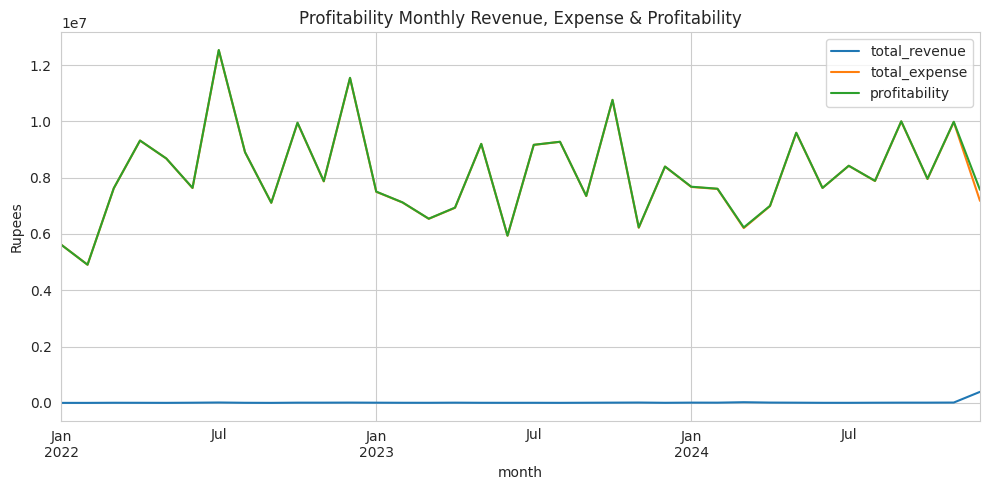

In [45]:
monthly_trend = panel.groupby("month")[["total_revenue","total_expense" , "profitability"]].sum()
plt.figure()
monthly_trend.plot(ax=plt.gca(),title = "Profitability Monthly Revenue, Expense & Profitability")
plt.ylabel("Rupees")
plt.tight_layout()
plt.show()

In [48]:
growth = monthly_trend["total_revenue"].pct_change().replace([np.inf, -np.inf],np.nan).mean()
print(f"Average month-on-month revenue growth: {growth:.1%}")

Average month-on-month revenue growth: 178.9%


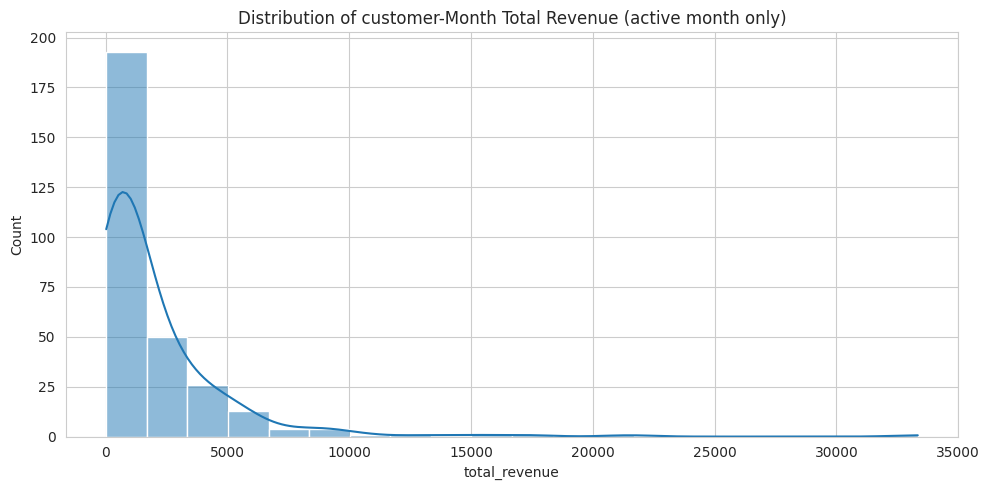

In [54]:
plt.figure()
sns.histplot(panel[panel["total_revenue"] > 0]["total_revenue"],bins=20,kde=True)
plt.title("Distribution of customer-Month Total Revenue (active month only)")
plt.tight_layout()
plt.show()

In [51]:
skew = panel[panel["total_revenue"] >0]["total_revenue"].skew()
print(f"Revenue distribution skew = {skew:.2f}")


Revenue distribution skew = 4.92


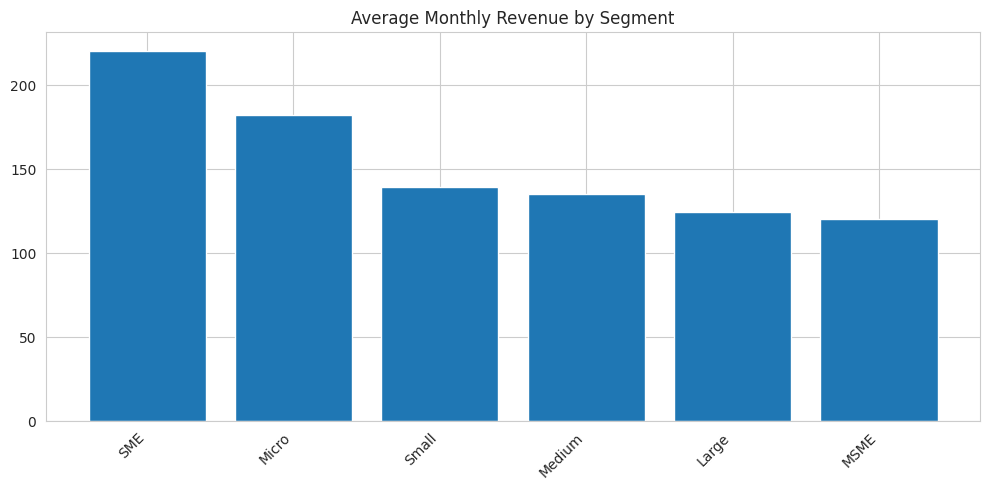

In [55]:
seg_revenue = panel.groupby("segment")["total_revenue"].mean().sort_values(ascending = False)
seg_labels = [str(v) for v in seg_revenue.index]

plt.figure()
plt.bar(seg_labels, seg_revenue.values)
plt.title("Average Monthly Revenue by Segment")
plt.xticks(rotation = 45, ha="right")
plt.tight_layout()
plt.show()

In [56]:
#one-way ANOVA
groups = [g["total_revenue"].values for _, g in panel.groupby("segment") if len(g) > 5]
f_stat, p_val = stats.f_oneway(*groups)
print(f"ANOVA: F = {f_stat:.2f}, p = {p_val:.4f}")
print("significant (p < 0.05) -> segment is worth keeping as a feature." if p_val < 0.05 else "Not Significant")

ANOVA: F = 0.96, p = 0.4413
Not Significant
